In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import SparkSession, DataFrame
from pyspark.ml.feature import Imputer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# setup the configuration


In [2]:
# Local run: no MinIO/S3 needed since we're reading/writing local parquet files.
# (Keep the s3a config block commented out for when you move this back to the cluster.)
spark = (
    SparkSession.builder.appName("clean_dataset")
    .master("local[*]")
    # .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    # .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    # .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
    # .config("spark.hadoop.fs.s3a.path.style.access", "true")
    # .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/10 12:44:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
IMPUTER_INPUT_COLS = ["anciennete_digitale_jours", "recence_gab_jours"]
IMPUTER_OUTPUT_COLS = ["anciennete_digitale_jours_imp", "recence_gab_jours_imp"]

# Local run: save the fitted Imputer model to a local folder instead of s3a://...
# (this was the cause of the crash: hadoop-aws jar isn't installed, so s3a:// paths fail)
IMPUTER_MODEL_PATH = "./models/imputer_anciennete_recence"


In [4]:
df = spark.read.parquet("part-00000.parquet")
df.show(100, truncate=False)


26/07/10 12:45:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------+------+-------+------+----+-------------+----------+-------------------+----+--------+--------------+-------------+---------------+---------------+----------+----------+-----------------+-----------+---------+-----------------------+-----------------------+-------------------+---------+----------+----------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+--------------------+----------------------+-----------+----------------------+---------------------+--------------------+-------------------+----------------------+
|RADICAL|BANQUE|AGENCE|GENERIC|PLURAL|CCLE|DATE_OF_BIRTH|CODE_VILLE|LIBELLE_VILLE      |BPR |GENDER  |MARITAL_STATUS|NOMBRE_ENFANT|CUSTOMER_RATING|TAILLE_ENTREPRI|age_client|label_code|label_nom        |pack_actuel|pack_etat|digital_date_activation|digital_toujours_abonne|solde_moyen        |solde_min|solde_max |nb_mois_observes_solde|depot_moyen       |flux_cred_moyen   |flux_cred_t

# Filtre doublons


In [5]:
# Vérification de l'unicité de RADICAL (clé de jointure, cf. guide maître 6.4/7.1)
# Normalement déjà dédoublonné en amont par build_dataset_final.py (row_number sur RADICAL),
# ce check sert juste à confirmer qu'aucune régression ne s'est glissée dans le parquet final.
total_lignes = df.count()
radical_distincts = df.select("RADICAL").distinct().count()
print(f"Lignes : {total_lignes} | RADICAL distincts : {radical_distincts}")

if total_lignes != radical_distincts:
    print(f"⚠️ {total_lignes - radical_distincts} RADICAL en double détectés — dédoublonnage nécessaire.")
else:
    print("✅ RADICAL est bien unique sur ce dataset.")


Lignes : 4144 | RADICAL distincts : 4008
⚠️ 136 RADICAL en double détectés — dédoublonnage nécessaire.


In [6]:
# Vérification des doublons stricts (lignes entièrement identiques), cf. guide maître section 7.6ter / 1218
total = df.count()
sans_doublons = df.dropDuplicates().count()
print("Total :", total, "| Sans doublons :", sans_doublons)

if total != sans_doublons:
    print(f"⚠️ {total - sans_doublons} doublons stricts détectés -> suppression")
    df = df.dropDuplicates()
else:
    print("✅ Aucun doublon strict détecté, pas besoin de relancer l'agrégation.")


Total : 4144 | Sans doublons : 4008
⚠️ 136 doublons stricts détectés -> suppression


In [7]:
# Suppression des doublons stricts (lignes entièrement identiques)
avant = df.count()
df = df.dropDuplicates()
apres = df.count()

print(f"Doublons supprimés : {avant - apres}")
print(f"Lignes avant : {avant} | Lignes après : {apres}")

Doublons supprimés : 0
Lignes avant : 4008 | Lignes après : 4008


# clean Data

In [8]:
df = df.withColumn(
    "GENDER",
    F.when(F.col("GENDER") == "FÃ©minin", "F")
     .when(F.col("GENDER") == "Masculin", "M")
     .otherwise(None)
)

In [9]:
for i, col in enumerate(df.columns):
    print(f"col {i}: {col} =>", df.filter(F.col(col).isNull()).count())


col 0: RADICAL => 0
col 1: BANQUE => 0
col 2: AGENCE => 0
col 3: GENERIC => 0
col 4: PLURAL => 0
col 5: CCLE => 0
col 6: DATE_OF_BIRTH => 0
col 7: CODE_VILLE => 0
col 8: LIBELLE_VILLE => 152
col 9: BPR => 2
col 10: GENDER => 1
col 11: MARITAL_STATUS => 0
col 12: NOMBRE_ENFANT => 266
col 13: CUSTOMER_RATING => 0
col 14: TAILLE_ENTREPRI => 4006
col 15: age_client => 0
col 16: label_code => 0
col 17: label_nom => 0
col 18: pack_actuel => 946
col 19: pack_etat => 946
col 20: digital_date_activation => 1385
col 21: digital_toujours_abonne => 0
col 22: solde_moyen => 0
col 23: solde_min => 0
col 24: solde_max => 0
col 25: nb_mois_observes_solde => 0
col 26: depot_moyen => 604
col 27: flux_cred_moyen => 0
col 28: flux_cred_total => 0
col 29: nb_mois_avec_flux => 0
col 30: nb_operations_gab => 0
col 31: montant_total_gab => 0
col 32: montant_moyen_gab => 1883
col 33: derniere_operation_gab => 1883
col 34: nb_retraits => 0
col 35: montant_total_retraits => 0
col 36: nb_paiements_digitaux => 0
c

In [10]:
df.select("LIBELLE_VILLE").distinct().show(truncate=False)

+-----------------+
|LIBELLE_VILLE    |
+-----------------+
|AIT BAHA         |
|IMZOUREN         |
|AHFIR            |
|FARKHANA         |
|BIOUGRA          |
|ZEGANGANE        |
|ET-TAOUS (TAOUZ) |
|MHAYA            |
|CHTOUKA          |
|SEBT GZOULA      |
|NADOR            |
|BOUARFA          |
|SIDI SMAIL       |
|IFRANE           |
|ASSA             |
|ERFOUD           |
|TIFLET           |
|ERRACHIDIA       |
|AL HOCEIMA       |
|AFOURAR (AFOURER)|
+-----------------+
only showing top 20 rows


In [11]:
df.groupBy("LIBELLE_VILLE").count().show()

+-----------------+-----+
|    LIBELLE_VILLE|count|
+-----------------+-----+
|         AIT BAHA|    5|
|         IMZOUREN|    2|
|            AHFIR|    6|
|         FARKHANA|    1|
|          BIOUGRA|    9|
|        ZEGANGANE|    5|
| ET-TAOUS (TAOUZ)|    2|
|            MHAYA|    2|
|          CHTOUKA|    2|
|      SEBT GZOULA|    1|
|            NADOR|   48|
|          BOUARFA|    8|
|       SIDI SMAIL|    1|
|           IFRANE|    5|
|             ASSA|    6|
|           ERFOUD|    7|
|           TIFLET|    8|
|       ERRACHIDIA|   21|
|       AL HOCEIMA|   13|
|AFOURAR (AFOURER)|    2|
+-----------------+-----+
only showing top 20 rows


# Script gestion des null

In [12]:
def clean_dataset(df: DataFrame) -> DataFrame:
    """
    Applique toutes les règles de nettoyage décidées pour ce projet.
    Chaque étape est commentée avec la décision métier qui la justifie
    (voir section 6.5 / 6.5bis du guide maître pour le détail).
    """

    n_avant = df.count()

    # --- 1. LIBELLE_VILLE : redondant avec CODE_VILLE (le code est fiable,
    #        0 null) -> on garde le code, on jette le libellé plutôt que
    #        d'imputer un texte qui n'apporte rien de plus au modèle ---
    if "LIBELLE_VILLE" in df.columns:
        df = df.drop("LIBELLE_VILLE")

    # --- 2. BPR / GENDER : nulls négligeables (2 et 1 lignes sur l'échantillon
    #        de référence) -> on supprime juste ces lignes, pas d'imputation ---
    subset_dropna = [c for c in ["BPR", "GENDER"] if c in df.columns]
    if subset_dropna:
        df = df.dropna(subset=subset_dropna)

    # --- 3. NOMBRE_ENFANT : null = pas d'enfant, PAS une valeur manquante
    #        à imputer par une médiane -> fillna(0) directement ---
    if "NOMBRE_ENFANT" in df.columns:
        df = df.fillna({"NOMBRE_ENFANT": 0})

    # --- 4. TAILLE_ENTREPRI : null = compte particulier (pas d'entreprise),
    #        pas une donnée manquante -> valeur catégorielle explicite.
    #        Devient un signal utile (particulier vs professionnel) au lieu
    #        d'être dropé ou imputé avec du bruit ---
    if "TAILLE_ENTREPRI" in df.columns:
        df = df.fillna({"TAILLE_ENTREPRI": "PARTICULIER"})

    # --- 4bis. pack_actuel / pack_etat : nulls groupés sur les mêmes clients
    #           (986 chacun) = clients sans pack digital, pas une vraie
    #           valeur manquante -> catégorie explicite, pas le mode ---
    pack_cols = {}
    if "pack_actuel" in df.columns:
        pack_cols["pack_actuel"] = "SANS_PACK"
    if "pack_etat" in df.columns:
        pack_cols["pack_etat"] = "SANS_ETAT"
    if pack_cols:
        df = df.fillna(pack_cols)

    # --- 5. depot_moyen / montant_moyen_gab : null = absence d'activité
    #        observée -> 0, cohérent avec le traitement déjà appliqué à
    #        flux_cred_moyen (NaN = 0, jamais une moyenne) ---
    montants_zero = [c for c in ["depot_moyen", "montant_moyen_gab"] if c in df.columns]
    if montants_zero:
        df = df.fillna({c: 0.0 for c in montants_zero})

    # --- 6. digital_date_activation : une date ne peut pas être mise à 0
    #        (serait confondu avec "activé aujourd'hui"). On dérive une
    #        ancienneté en jours + un flag explicite, puis on jette la
    #        date brute qui n'est de toute façon pas exploitable telle
    #        quelle par VectorAssembler ---
    if "digital_date_activation" in df.columns:
        df = (
            df.withColumn(
                "jamais_active_digital",
                F.when(F.col("digital_date_activation").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "anciennete_digitale_jours",
                F.when(F.col("digital_date_activation").isNull(), F.lit(None))
                .otherwise(
                    F.datediff(
                        F.current_date(),
                        F.to_date("digital_date_activation", "dd/MM/yyyy"),
                    )
                ),
            )
            .drop("digital_date_activation")
        )

    # --- 7. derniere_operation_gab : même logique que #6, format datetime ---
    if "derniere_operation_gab" in df.columns:
        df = (
            df.withColumn(
                "jamais_utilise_gab",
                F.when(F.col("derniere_operation_gab").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "recence_gab_jours",
                F.when(F.col("derniere_operation_gab").isNull(), F.lit(None))
                .otherwise(
                    F.datediff(
                        F.current_date(),
                        F.to_date(
                            F.col("derniere_operation_gab"), "dd/MM/yyyy HH:mm:ss"
                        ),
                    )
                ),
            )
            .drop("derniere_operation_gab")
        )

    n_apres = df.count()
    print(f"    Lignes avant : {n_avant} | après (dropna BPR/GENDER) : {n_apres}")

    return df

In [13]:
def run(path_in: str, path_out: str, label: str):
    print(f"\n{'=' * 20} NETTOYAGE : {label} {'=' * 20}")
    print(f"Lecture : {path_in}")
    df = spark.read.parquet(path_in)

    print("Nulls avant nettoyage :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    df_clean = clean_dataset(df)

    print("Nulls après nettoyage :")
    df_clean.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns]
    ).show(truncate=False, vertical=True)

    print(f"Écriture : {path_out}")
    df_clean.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} nettoyé et écrit.\n")


In [14]:
def apply_base_cleaning(path_in: str, label: str) -> DataFrame:
    print(f"\n{'=' * 20} NETTOYAGE DE BASE : {label} {'=' * 20}")
    print(f"Lecture : {path_in}")
    df = spark.read.parquet(path_in)

    print("Nulls avant nettoyage :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    df_clean = clean_dataset(df)
    return df_clean

In [15]:
def fit_and_apply_imputer_on_train(df_train: DataFrame) -> DataFrame:
    """
    Option A : Imputer (médiane) sur anciennete_digitale_jours / recence_gab_jours.
    Fit UNIQUEMENT sur le train (clients_avec_label) -- jamais sur la population
    à scorer, pour éviter toute fuite d'information et rester cohérent avec la
    logique déjà utilisée pour le Pipeline MLlib (fit sur train, transform partout).
    Le modèle d'imputation est sauvegardé pour être réappliqué tel quel sur
    dataset_a_scorer (mêmes médianes, pas recalculées).

    Les colonnes brutes (anciennete_digitale_jours / recence_gab_jours) sont
    droppées après imputation : seules les versions *_imp (sans null) doivent
    entrer dans le VectorAssembler, aux côtés des flags jamais_active_digital /
    jamais_utilise_gab qui permettent au modèle de distinguer une vraie valeur
    d'une médiane fictive.
    """
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_train.columns]
    if not cols_present:
        return df_train

    out_cols = [IMPUTER_OUTPUT_COLS[IMPUTER_INPUT_COLS.index(c)] for c in cols_present]

    imputer = Imputer(inputCols=cols_present, outputCols=out_cols, strategy="median")
    imputer_model = imputer.fit(df_train)

    medianes = {c: df_train.approxQuantile(c, [0.5], 0.01)[0] for c in cols_present}
    print(f"Médianes apprises sur le train : {medianes}")

    df_train_imp = imputer_model.transform(df_train)

    print(f"Sauvegarde du modèle d'imputation : {IMPUTER_MODEL_PATH}")
    imputer_model.write().overwrite().save(IMPUTER_MODEL_PATH)

    # Drop des colonnes brutes une fois les versions _imp calculées
    df_train_imp = df_train_imp.drop(*cols_present)

    return df_train_imp


In [16]:
def apply_saved_imputer(df_scorer: DataFrame) -> DataFrame:
    """Recharge l'Imputer entraîné sur le train et l'applique tel quel au
    dataset à scorer -- mêmes médianes des deux côtés, aucune fuite.
    Droppe aussi les colonnes brutes après imputation, comme sur le train."""
    from pyspark.ml.feature import ImputerModel

    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_scorer.columns]
    if not cols_present:
        return df_scorer

    print(f"Chargement du modèle d'imputation : {IMPUTER_MODEL_PATH}")
    imputer_model = ImputerModel.load(IMPUTER_MODEL_PATH)
    df_scorer_imp = imputer_model.transform(df_scorer)

    # Drop des colonnes brutes une fois les versions _imp calculées
    df_scorer_imp = df_scorer_imp.drop(*cols_present)

    return df_scorer_imp


In [17]:
def show_nulls_and_write(df: DataFrame, path_out: str, label: str):
    print("Nulls après nettoyage complet (base + imputation) :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    print(f"Écriture : {path_out}")
    df.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} nettoyé et écrit.\n")

In [18]:
if __name__ == "__main__":
    import os

    # Adapter ce chemin si votre nom de dossier Parquet diffère
    PATH_TRAIN_IN = "part-00000.parquet"

    # Nom de sortie = nom du fichier d'entrée + "_clean"
    # ex: "part-00000.parquet" -> "part-00000_clean.parquet"
    _base, _ext = os.path.splitext(PATH_TRAIN_IN)
    PATH_TRAIN_OUT = f"{_base}_clean{_ext}"

    # 1. Nettoyage de base + fit de l'Imputer SUR LE TRAIN UNIQUEMENT
    df_train = apply_base_cleaning(PATH_TRAIN_IN, "dataset_train_produits (clients avec label)")
    df_train = fit_and_apply_imputer_on_train(df_train)
    show_nulls_and_write(df_train, PATH_TRAIN_OUT, "dataset_train_produits (clients avec label)")

    print("\nTerminé. anciennete_digitale_jours_imp / recence_gab_jours_imp sont")
    print("désormais sans null (médianes apprises sur le train, réutilisées pour")
    print("le scoring). Utiliser les colonnes *_imp (pas les brutes) dans le")
    print("VectorAssembler, aux côtés des flags jamais_active_digital / jamais_utilise_gab.")
    print(f"\nFichier de sortie : {PATH_TRAIN_OUT}")



==================== NETTOYAGE DE BASE : dataset_train_produits (clients avec label) ====================
Lecture : part-00000.parquet


Nulls avant nettoyage :
-RECORD 0-----------------------
 RADICAL                 | 0    
 BANQUE                  | 0    
 AGENCE                  | 0    
 GENERIC                 | 0    
 PLURAL                  | 0    
 CCLE                    | 0    
 DATE_OF_BIRTH           | 0    
 CODE_VILLE              | 0    
 LIBELLE_VILLE           | 155  
 BPR                     | 2    
 GENDER                  | 1    
 MARITAL_STATUS          | 0    
 NOMBRE_ENFANT           | 267  
 CUSTOMER_RATING         | 0    
 TAILLE_ENTREPRI         | 4140 
 age_client              | 0    
 label_code              | 0    
 label_nom               | 0    
 pack_actuel             | 987  
 pack_etat               | 987  
 digital_date_activation | 1385 
 digital_toujours_abonne | 0    
 solde_moyen             | 0    
 solde_min               | 0    
 solde_max               | 0    
 nb_mois_observes_solde  | 0    
 depot_moyen             | 605  
 flux_cred_moyen         | 0    
 flux_cred_total   

# script B: gestion des outliners

In [19]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
 
# Colonnes de comptage : doivent toujours être >= 0 (une valeur négative est
# une erreur de données, jamais un "petit outlier")
COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde", "nb_mois_avec_flux", "nb_operations_gab",
    "nb_retraits", "nb_paiements_digitaux", "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]
 
# Colonnes de montant qui doivent toujours être >= 0 (des totaux/moyennes de
# mouvements positifs par construction -- contrairement à solde_min/solde_max
# qui PEUVENT être négatifs, un compte pouvant être à découvert)
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen", "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]
 
# Colonnes candidates au plafonnement statistique (catégorie 2). On y met
# toutes les colonnes financières/comportementales continues, y compris
# solde_min/solde_max qui peuvent légitimement être négatives.
COLS_A_PLAFONNER = [
    "solde_moyen", "solde_min", "solde_max", "depot_moyen",
    "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]
 
IQR_K = 1.5  # multiplicateur IQR standard (Tukey) -- élargir à 2.0 ou 3.0
             # si trop de clients légitimes se retrouvent plafonnés (voir
             # le rapport de diagnostic avant de choisir)
 
OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"
 


In [20]:
# ---------------------------------------------------------------------------
# Étape 0 — Diagnostic (à lancer et lire AVANT de choisir quoi que ce soit)
# ---------------------------------------------------------------------------
 
def rapport_diagnostic(df: DataFrame, cols: list[str] | None = None) -> None:
    """
    Affiche min / max / moyenne / médiane / quantiles 1%-99% pour chaque
    colonne numérique -- pour repérer à l'oeil les valeurs suspectes avant
    de fixer des règles. Même logique que le comptage de nulls déjà fait
    dans clean_dataset.py (cellule 7 du notebook) : on regarde d'abord,
    on décide ensuite.
    """
    if cols is None:
        cols = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float")]
 
    print(f"\n{'=' * 20} DIAGNOSTIC VALEURS ABERRANTES {'=' * 20}")
    for c in cols:
        if c not in df.columns:
            continue
        stats = df.select(
            F.min(c).alias("min"),
            F.max(c).alias("max"),
            F.mean(c).alias("mean"),
        ).collect()[0]
        q1, med, q3, p01, p99 = df.approxQuantile(
            c, [0.25, 0.5, 0.75, 0.01, 0.99], 0.01
        )
        iqr = q3 - q1
        borne_basse = q1 - IQR_K * iqr
        borne_haute = q3 + IQR_K * iqr
        n_negatifs = df.filter(F.col(c) < 0).count()
        n_hors_bornes = df.filter(
            (F.col(c) < borne_basse) | (F.col(c) > borne_haute)
        ).count()
        print(
            f"{c:28s} min={stats['min']!s:>14} max={stats['max']!s:>16} "
            f"mean={stats['mean']:.1f}  médiane={med:.1f}  "
            f"p1={p01:.1f} p99={p99:.1f}  "
            f"bornes_IQR=[{borne_basse:.1f}, {borne_haute:.1f}]  "
            f"négatifs={n_negatifs}  hors_bornes_IQR={n_hors_bornes}"
        )
 
 
def rapport_dates_naissance(df: DataFrame, col: str = "DATE_OF_BIRTH") -> None:
    """Diagnostic spécifique DATE_OF_BIRTH : âges implausibles (<16 ou >100
    ans, ou date dans le futur). Format attendu dd/MM/yyyy (voir aperçu du
    fichier PERIMETRE dans le rapport de données)."""
    if col not in df.columns:
        return
    df_age = df.withColumn(
        "_age_tmp",
        F.floor(F.datediff(F.current_date(), F.to_date(F.col(col), "dd/MM/yyyy")) / 365.25),
    )
    print(f"\n{'=' * 20} DIAGNOSTIC {col} {'=' * 20}")
    df_age.select(
        F.min("_age_tmp").alias("age_min"),
        F.max("_age_tmp").alias("age_max"),
    ).show()
    n_futur = df_age.filter(F.col("_age_tmp") < 0).count()
    n_trop_jeune = df_age.filter((F.col("_age_tmp") >= 0) & (F.col("_age_tmp") < 16)).count()
    n_trop_vieux = df_age.filter(F.col("_age_tmp") > 100).count()
    print(f"Dates dans le futur (âge négatif) : {n_futur}")
    print(f"Âge < 16 ans : {n_trop_jeune}")
    print(f"Âge > 100 ans : {n_trop_vieux}")

In [21]:
# ---------------------------------------------------------------------------
# Étape 1 — Valeurs impossibles (règles métier, catégorie 1)
# ---------------------------------------------------------------------------

SEUIL_MAX_MOIS_OBSERVES = 36  # 12*3 : au-delà, jugé non plausible (probable
                               # doublon de jointure, cf. investigation)


def corriger_valeurs_impossibles(df: DataFrame, is_train: bool) -> DataFrame:
    """
    Corrige les erreurs de données pures (pas des outliers statistiques) :
    compteurs négatifs, montants négatifs qui ne devraient jamais l'être,
    dates de naissance impossibles, nb_mois_observes_solde aberrant.

    is_train=True  -> les (rares) lignes vraiment incohérentes peuvent être
                       supprimées (ex. date de naissance dans le futur).
    is_train=False -> RIEN n'est supprimé (population à scorer) : les
                       valeurs impossibles sont corrigées en les ramenant à
                       une valeur plancher (0), jamais en droppant la ligne.
    """
    n_avant = df.count()

    # --- Compteurs qui ne peuvent pas être négatifs ---
    for c in COLS_COMPTAGE_NON_NEGATIVES:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0).otherwise(F.col(c)))

    # --- nb_mois_observes_solde anormalement élevé (probable doublon de
    #     jointure : IQR = 0 sur cette colonne, donc pas gérable par le
    #     plafonnement statistique -> règle métier dure ici) ---
    c_mois = "nb_mois_observes_solde"
    if c_mois in df.columns:
        n_suspect = df.filter(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES).count()
        if n_suspect > 0:
            print(f"  {c_mois} : {n_suspect} valeur(s) > {SEUIL_MAX_MOIS_OBSERVES} mois -> plafonnées à {SEUIL_MAX_MOIS_OBSERVES}")
        df = df.withColumn(
            f"{c_mois}_etait_extreme",
            F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, 1).otherwise(0),
        )
        df = df.withColumn(
            c_mois,
            F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, F.lit(SEUIL_MAX_MOIS_OBSERVES)).otherwise(F.col(c_mois)),
        )

    # --- Montants qui ne peuvent pas être négatifs (attention : ne PAS
    #     appliquer ça à solde_min/solde_max, un découvert est légitime) ---
    for c in COLS_MONTANT_NON_NEGATIFS:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0.0).otherwise(F.col(c)))

    # --- Dates de naissance impossibles ---
    if "DATE_OF_BIRTH" in df.columns:
        df = df.withColumn(
            "_age_tmp",
            F.floor(F.datediff(F.current_date(), F.to_date(F.col("DATE_OF_BIRTH"), "dd/MM/yyyy")) / 365.25),
        )
        n_suspect = df.filter((F.col("_age_tmp") < 16) | (F.col("_age_tmp") > 100)).count()
        if is_train:
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (<16 ou >100 ans) -> lignes supprimées (train)")
            df = df.filter((F.col("_age_tmp") >= 16) & (F.col("_age_tmp") <= 100))
        else:
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (scoring, non supprimés)")
        df = df.drop("_age_tmp")

    n_apres = df.count()
    if is_train:
        print(f"  Lignes avant/après (valeurs impossibles, train) : {n_avant} -> {n_apres}")
        

    return df

In [22]:
# ---------------------------------------------------------------------------
# Étape 2 — Plafonnement statistique (winsorisation, catégorie 2)
#           Fit sur train uniquement, sauvegarde, réapplication sur scoring
#           (même logique de non-fuite que l'Imputer déjà en place).
# ---------------------------------------------------------------------------
 
def apprendre_bornes_plafonnement(df_train: DataFrame, cols: list[str] | None = None) -> dict:
    """Calcule les bornes IQR (Tukey, k=IQR_K) sur le train UNIQUEMENT, les
    sauvegarde en JSON pour être réappliquées telles quelles sur le scoring."""
    if cols is None:
        cols = COLS_A_PLAFONNER
 
    bornes = {}
    for c in cols:
        if c not in df_train.columns:
            continue
        q1, q3 = df_train.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1
        bornes[c] = {
            "min": q1 - IQR_K * iqr,
            "max": q3 + IQR_K * iqr,
        }
 
    print(f"\nBornes de plafonnement apprises sur le train ({len(bornes)} colonnes) :")
    for c, b in bornes.items():
        print(f"  {c:28s} -> [{b['min']:.1f}, {b['max']:.1f}]")
 
    os.makedirs(os.path.dirname(OUTLIER_BOUNDS_PATH), exist_ok=True)
    with open(OUTLIER_BOUNDS_PATH, "w") as f:
        json.dump(bornes, f, indent=2)
    print(f"Bornes sauvegardées : {OUTLIER_BOUNDS_PATH}")
 
    return bornes
 
 
def charger_bornes_plafonnement() -> dict:
    with open(OUTLIER_BOUNDS_PATH) as f:
        return json.load(f)
 
 
def appliquer_plafonnement(df: DataFrame, bornes: dict, ajouter_flags: bool = True) -> DataFrame:
    """
    Plafonne chaque colonne à [min, max] (winsorisation) -- ne supprime
    jamais de ligne, quel que soit train ou scoring. Ajoute optionnellement
    un flag <col>_etait_extreme (0/1) pour que le modèle puisse distinguer
    une vraie valeur d'une valeur plafonnée, même logique que les flags
    jamais_active_digital / jamais_utilise_gab déjà en place.
    """
    n_plafonnes_total = 0
    for c, b in bornes.items():
        if c not in df.columns:
            continue
        lo, hi = b["min"], b["max"]
 
        if ajouter_flags:
            df = df.withColumn(
                f"{c}_etait_extreme",
                F.when((F.col(c) < lo) | (F.col(c) > hi), 1).otherwise(0),
            )
 
        n_hors = df.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
        n_plafonnes_total += n_hors
        if n_hors > 0:
            print(f"  {c} : {n_hors} valeur(s) plafonnée(s) vers [{lo:.1f}, {hi:.1f}]")
 
        df = df.withColumn(
            c,
            F.when(F.col(c) < lo, F.lit(lo))
             .when(F.col(c) > hi, F.lit(hi))
             .otherwise(F.col(c)),
        )
 
    print(f"  Total valeurs plafonnées (toutes colonnes) : {n_plafonnes_total}")
    return df
 

In [23]:
COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde",
    "nb_mois_avec_flux",
    "nb_operations_gab",
    "nb_retraits",
    "nb_paiements_digitaux",
    "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]

# ATTENTION : solde_moyen, solde_min, solde_max sont volontairement EXCLUS
# ici -> un découvert (solde négatif) est un état de compte parfaitement
# légitime, pas une erreur de saisie.
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen",
    "flux_cred_moyen",
    "flux_cred_total",
    "montant_total_gab",
    "montant_moyen_gab",
    "montant_total_retraits",
    "montant_total_payfac",
    "montant_total_vignette",
]

COLS_A_PLAFONNER = [
    "solde_moyen",
    "solde_min",
    "solde_max",
    "depot_moyen",
    "flux_cred_moyen",
    "flux_cred_total",
    "montant_total_gab",
    "montant_moyen_gab",
    "montant_total_retraits",
    "montant_total_payfac",
    "montant_total_vignette",
]

IQR_K = 1.5  # facteur de Tukey standard
OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"

SEUIL_MAX_MOIS_OBSERVES = 36  # 12*3 : au-delà, jugé non plausible (probable
                               # doublon de jointure)


# ---------------------------------------------------------------------------
# Étape 1 — Valeurs impossibles (règles métier, catégorie 1)
# ---------------------------------------------------------------------------

def corriger_valeurs_impossibles(df: DataFrame, is_train: bool) -> DataFrame:
    n_avant = df.count()

    # --- Compteurs qui ne peuvent pas être négatifs (inclut NOMBRE_ENFANT) ---
    for c in COLS_COMPTAGE_NON_NEGATIVES:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0).otherwise(F.col(c)))

    # --- nb_mois_observes_solde anormalement élevé (seuil métier, IQR=0) ---
    c_mois = "nb_mois_observes_solde"
    if c_mois in df.columns:
        n_suspect = df.filter(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES).count()
        if n_suspect > 0:
            print(f"  {c_mois} : {n_suspect} valeur(s) > {SEUIL_MAX_MOIS_OBSERVES} mois -> plafonnées à {SEUIL_MAX_MOIS_OBSERVES}")
        df = df.withColumn(
            f"{c_mois}_etait_extreme",
            F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, 1).otherwise(0),
        )
        df = df.withColumn(
            c_mois,
            F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, F.lit(SEUIL_MAX_MOIS_OBSERVES)).otherwise(F.col(c_mois)),
        )

    # --- NOMBRE_ENFANT anormalement élevé (seuil métier, IQR trop resserré) ---
    SEUIL_MAX_ENFANTS = 12
    c_enfants = "NOMBRE_ENFANT"
    if c_enfants in df.columns:
        n_suspect = df.filter(F.col(c_enfants) > SEUIL_MAX_ENFANTS).count()
        if n_suspect > 0:
            print(f"  {c_enfants} : {n_suspect} valeur(s) > {SEUIL_MAX_ENFANTS} -> plafonnées à {SEUIL_MAX_ENFANTS}")
        df = df.withColumn(
            f"{c_enfants}_etait_extreme",
            F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, 1).otherwise(0),
        )
        df = df.withColumn(
            c_enfants,
            F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, F.lit(SEUIL_MAX_ENFANTS)).otherwise(F.col(c_enfants)),
        )

    # --- Montants qui ne peuvent pas être négatifs ---
    for c in COLS_MONTANT_NON_NEGATIFS:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0.0).otherwise(F.col(c)))

    # --- Dates de naissance impossibles ---
    # ... (inchangé)

    n_apres = df.count()
    if is_train:
        print(f"  Lignes avant/après (valeurs impossibles, train) : {n_avant} -> {n_apres}")

    return df

# ---------------------------------------------------------------------------
# Étape 2 — Plafonnement statistique (winsorisation, catégorie 2)
#           Fit sur train uniquement, sauvegarde, réapplication sur scoring
#           (même logique de non-fuite que l'Imputer déjà en place).
# ---------------------------------------------------------------------------

def detecter_colonnes_zero_inflated(
    df_train: DataFrame,
    cols: list[str],
    seuil_part_zero: float = 0.5,
) -> set[str]:
    """
    Détecte automatiquement, sur le train, les colonnes 'zero-inflated' :
    celles où une proportion importante des valeurs vaut 0 (non-usage
    légitime : pas d'opération GAB, pas de vignette payée, etc.).

    Pour ces colonnes, un IQR calculé sur la colonne entière s'effondre
    souvent à [0, 0] (Q1 = Q3 = 0), ce qui écraserait à 0 toute valeur
    réelle non nulle lors du plafonnement -> il faut calculer les
    quantiles sur le sous-ensemble des valeurs > 0 pour ces colonnes.
    """
    n_total = df_train.count()
    zero_inflated = set()
    for c in cols:
        if c not in df_train.columns:
            continue
        n_zero = df_train.filter(F.col(c) == 0).count()
        part_zero = n_zero / n_total if n_total else 0
        if part_zero >= seuil_part_zero:
            zero_inflated.add(c)
            print(f"  {c:28s} -> zero-inflated détectée ({part_zero:.0%} de zéros)")
    return zero_inflated


def apprendre_bornes_plafonnement(df_train: DataFrame, cols: list[str] | None = None) -> dict:
    """Calcule les bornes IQR (Tukey, k=IQR_K) sur le train UNIQUEMENT, les
    sauvegarde en JSON pour être réappliquées telles quelles sur le scoring.

    Pour les colonnes zero-inflated (détectées automatiquement), les
    quantiles sont calculés sur le sous-ensemble des valeurs strictement
    positives, sinon Q1=Q3=0 et les bornes s'effondrent à [0, 0].
    """
    if cols is None:
        cols = COLS_A_PLAFONNER

    print("\nDétection des colonnes zero-inflated (train) :")
    cols_zero_inflated = detecter_colonnes_zero_inflated(df_train, cols)

    bornes = {}
    for c in cols:
        if c not in df_train.columns:
            continue

        est_zero_inflated = c in cols_zero_inflated
        base_df = df_train.filter(F.col(c) > 0) if est_zero_inflated else df_train

        n_base = base_df.count()
        if n_base < 10:
            print(f"  {c:28s} -> ignorée (trop peu de valeurs exploitables : {n_base})")
            continue

        q1, q3 = base_df.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1

        if iqr == 0:
            print(f"  {c:28s} -> ignorée (IQR nul même sur valeurs > 0)")
            continue

        lo = q1 - IQR_K * iqr
        hi = q3 + IQR_K * iqr

        if est_zero_inflated:
            # Les zéros sont légitimes (non-usage) : jamais de borne basse
            # au-dessus de 0, sinon on rejetterait les zéros eux-mêmes.
            lo = min(lo, 0.0)

        bornes[c] = {"min": lo, "max": hi}

    print(f"\nBornes de plafonnement apprises sur le train ({len(bornes)} colonnes) :")
    for c, b in bornes.items():
        tag = " [zero-inflated, quantiles sur valeurs > 0]" if c in cols_zero_inflated else ""
        print(f"  {c:28s} -> [{b['min']:.1f}, {b['max']:.1f}]{tag}")

    os.makedirs(os.path.dirname(OUTLIER_BOUNDS_PATH), exist_ok=True)
    with open(OUTLIER_BOUNDS_PATH, "w") as f:
        json.dump(bornes, f, indent=2)
    print(f"Bornes sauvegardées : {OUTLIER_BOUNDS_PATH}")

    return bornes


def charger_bornes_plafonnement() -> dict:
    with open(OUTLIER_BOUNDS_PATH) as f:
        return json.load(f)


def appliquer_plafonnement(df: DataFrame, bornes: dict, ajouter_flags: bool = True) -> DataFrame:
    """
    Plafonne chaque colonne à [min, max] (winsorisation) -- ne supprime
    jamais de ligne, quel que soit train ou scoring. Ajoute optionnellement
    un flag <col>_etait_extreme (0/1) pour que le modèle puisse distinguer
    une vraie valeur d'une valeur plafonnée.
    """
    n_plafonnes_total = 0
    for c, b in bornes.items():
        if c not in df.columns:
            continue
        lo, hi = b["min"], b["max"]

        if ajouter_flags:
            df = df.withColumn(
                f"{c}_etait_extreme",
                F.when((F.col(c) < lo) | (F.col(c) > hi), 1).otherwise(0),
            )

        n_hors = df.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
        n_plafonnes_total += n_hors
        if n_hors > 0:
            print(f"  {c} : {n_hors} valeur(s) plafonnée(s) vers [{lo:.1f}, {hi:.1f}]")

        df = df.withColumn(
            c,
            F.when(F.col(c) < lo, F.lit(lo))
             .when(F.col(c) > hi, F.lit(hi))
             .otherwise(F.col(c)),
        )

    print(f"  Total valeurs plafonnées (toutes colonnes) : {n_plafonnes_total}")
    return df




In [24]:

# ---------------------------------------------------------------------------
# Orchestration — à insérer dans le main() existant de clean_dataset.py,
# juste après apply_base_cleaning() / avant fit_and_apply_imputer_on_train()
# ---------------------------------------------------------------------------
import json
 
def traiter_valeurs_aberrantes_train(df_train: DataFrame) -> DataFrame:
    print(f"\n{'=' * 20} VALEURS ABERRANTES : TRAIN {'=' * 20}")
    rapport_diagnostic(df_train, COLS_A_PLAFONNER)
    rapport_dates_naissance(df_train)
 
    df_train = corriger_valeurs_impossibles(df_train, is_train=True)
    bornes = apprendre_bornes_plafonnement(df_train)
    df_train = appliquer_plafonnement(df_train, bornes)
    return df_train
 
 
def traiter_valeurs_aberrantes_scoring(df_scorer: DataFrame) -> DataFrame:
    print(f"\n{'=' * 20} VALEURS ABERRANTES : SCORING {'=' * 20}")
    df_scorer = corriger_valeurs_impossibles(df_scorer, is_train=False)
    bornes = charger_bornes_plafonnement()
    df_scorer = appliquer_plafonnement(df_scorer, bornes)
    return df_scorer
 
 
if __name__ == "__main__":
    # Exemple d'usage autonome pour tester sur part-00000_clean.parquet
    # (sortie de clean_dataset.py), avant intégration dans le main() complet.
    from pyspark.sql import SparkSession
 
    spark = (
        SparkSession.builder.appName("outliers_dataset")
        .master("local[*]")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
 
    df = spark.read.parquet("part-00000_clean.parquet")
    df = traiter_valeurs_aberrantes_train(df)
    df.write.mode("overwrite").parquet("part-00000_clean_noutliers.parquet")
    print("\nOK : écrit dans part-00000_clean_noutliers.parquet")
 

26/07/10 12:45:37 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.



==================== VALEURS ABERRANTES : TRAIN ====================

==================== DIAGNOSTIC VALEURS ABERRANTES ====================
solde_moyen                  min=-97563.33041666668 max=9125344.346666666 mean=58168.6  médiane=6189.1  p1=-97563.3 p99=9125344.3  bornes_IQR=[-47414.3, 79296.3]  négatifs=930  hors_bornes_IQR=576
solde_min                    min=    -609921.11 max=      9125170.18 mean=10966.7  médiane=0.0  p1=-609921.1 p99=9125170.2  bornes_IQR=[-4270.2, 4078.6]  négatifs=2023  hors_bornes_IQR=1142
solde_max                    min=     -80569.92 max=     19529843.52 mean=176933.7  médiane=28654.0  p1=-80569.9 p99=19529843.5  bornes_IQR=[-170523.9, 291488.4]  négatifs=598  hors_bornes_IQR=518
depot_moyen                  min=           0.0 max=9125398.980000002 mean=120567.5  médiane=12237.6  p1=0.0 p99=9125399.0  bornes_IQR=[-100695.9, 169849.8]  négatifs=0  hors_bornes_IQR=602
flux_cred_moyen              min=           0.0 max=      2693225.05 mean=25827.3  

In [25]:
def plot_boxplot(df, column_name):
    print(f"Extraction des données pour : {column_name}...")

    data = (
        df.select(column_name)
          .toPandas()[column_name]
    )

    # Conversion en numérique
    data = pd.to_numeric(data, errors="coerce")

    # Suppression des valeurs manquantes
    data = data.dropna()

    print(data.dtype)
    print(data.describe())

    plt.figure(figsize=(10, 3))
    sns.boxplot(x=data)
    plt.title(f"Distribution et Outliers : {column_name}")
    plt.xlabel(column_name)
    plt.show()

In [26]:
# for col in df.columns:
#    plot_boxplot(df, col)

In [27]:
df.groupBy("NOMBRE_ENFANT_etait_extreme").count().show()

+---------------------------+-----+
|NOMBRE_ENFANT_etait_extreme|count|
+---------------------------+-----+
|                          1|    1|
|                          0| 4140|
+---------------------------+-----+



# Réduction des dimensions ciblé

In [34]:
# ---------------------------------------------------------------------------
# 1) Drop des colonnes techniques (clé de jointure / IBAN, aucune valeur prédictive)
# ---------------------------------------------------------------------------
cols_techniques = ["RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "CCLE"]
df_features = df.drop(*cols_techniques)

print(f"Colonnes avant : {len(df.columns)} | après drop technique : {len(df_features.columns)}")


Colonnes avant : 45 | après drop technique : 45


In [35]:
# ---------------------------------------------------------------------------
# 2) Matrice de corrélation sur les colonnes numériques -> repérer les redondances
# ---------------------------------------------------------------------------
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

# On exclut la cible et les colonnes non numériques (catégorielles, dates, etc.)
cols_a_exclure = ["label_code", "label_nom"]
cols_numeriques = [
    c for c, t in df_features.dtypes
    if t in ("int", "bigint", "double", "float") and c not in cols_a_exclure
]
print(f"{len(cols_numeriques)} colonnes numériques analysées :", cols_numeriques)

assembler = VectorAssembler(inputCols=cols_numeriques, outputCol="features_corr", handleInvalid="skip")
vec_df = assembler.transform(df_features).select("features_corr")

matrix = Correlation.corr(vec_df, "features_corr").head()[0].toArray()
corr_pd = pd.DataFrame(matrix, index=cols_numeriques, columns=cols_numeriques)


35 colonnes numériques analysées : ['NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'NOMBRE_ENFANT_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_gab_etait_extreme', 'montant_moyen_gab_etait_extreme', 'montant_total_retraits_etait_extreme', 'montant_total_payfac_etait_extreme', 'montant_total_vignette_etait_extreme', 'solde_volatilite_relative']


26/07/10 12:46:25 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


In [36]:
# ---------------------------------------------------------------------------
# 3) Lister les paires fortement corrélées (seuil 0.85) -> candidates à supprimer
# ---------------------------------------------------------------------------
seuil = 0.85
paires_redondantes = []

for i in range(len(cols_numeriques)):
    for j in range(i + 1, len(cols_numeriques)):
        r = corr_pd.iloc[i, j]
        if abs(r) >= seuil:
            paires_redondantes.append((cols_numeriques[i], cols_numeriques[j], round(r, 3)))

print(f"\n{len(paires_redondantes)} paire(s) fortement corrélée(s) (|r| >= {seuil}) :")
for a, b, r in paires_redondantes:
    print(f"  {a}  <->  {b}   (r = {r})")


1 paire(s) fortement corrélée(s) (|r| >= 0.85) :
  montant_moyen_gab  <->  montant_moyen_gab_etait_extreme   (r = 0.866)


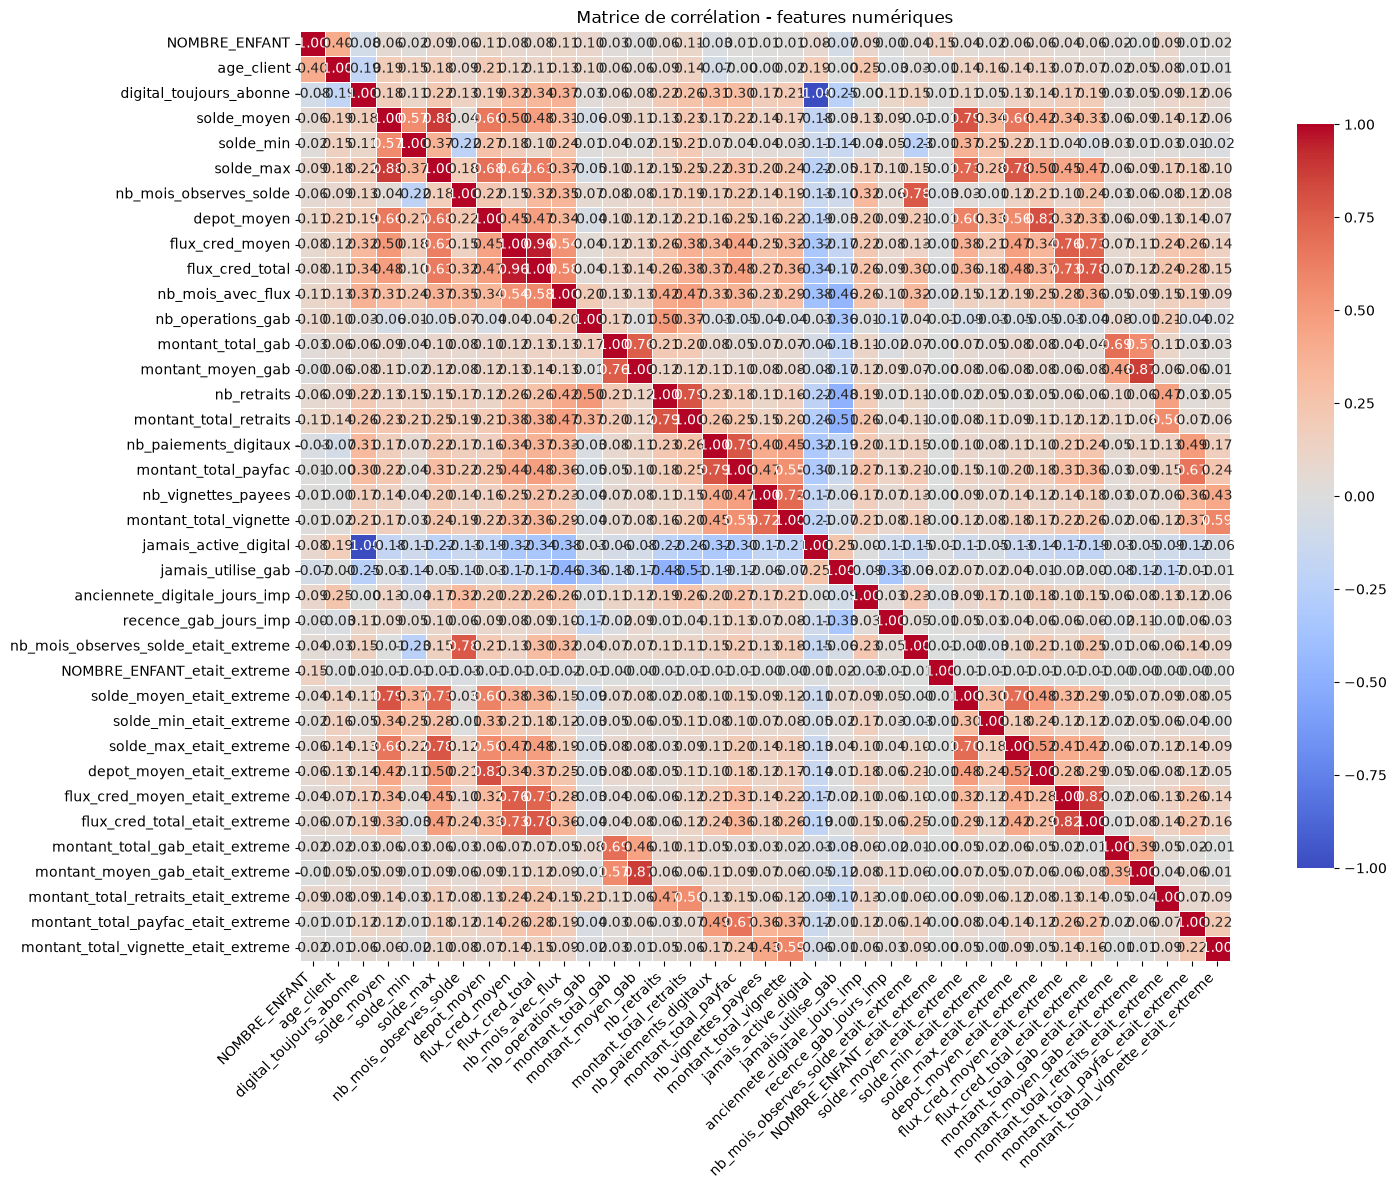

In [31]:
# ---------------------------------------------------------------------------
# Visualisation de la matrice de corrélation (heatmap)
# ---------------------------------------------------------------------------
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_pd,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de corrélation - features numériques")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Nettoyage final des variables + ajout de age_client


In [32]:
# ---------------------------------------------------------------------------
# 1) Colonnes techniques (clé de compte / IBAN interne) -> aucune valeur prédictive
# ---------------------------------------------------------------------------
cols_techniques = ["RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "CCLE"]
df = df.drop(*[c for c in cols_techniques if c in df.columns])

# ---------------------------------------------------------------------------
# 2) digital_toujours_abonne <-> jamais_active_digital (r = -0.999, quasi doublon)
#    -> on garde jamais_active_digital, on drop digital_toujours_abonne
# ---------------------------------------------------------------------------
df = df.drop("digital_toujours_abonne")

# ---------------------------------------------------------------------------
# 3) solde_moyen <-> solde_max (r = 0.878) -> remplacé par une volatilité RELATIVE
#    (un écart absolu reste corrélé à solde_moyen par simple effet d'échelle :
#    un gros solde varie plus en valeur brute sans être plus "instable").
#    Protégé contre solde_moyen <= 0 (découvert / proche de zéro) -> null plutôt
#    qu'un ratio qui explose ou n'a pas de sens.
# ---------------------------------------------------------------------------
df = (
    df.withColumn(
        "solde_volatilite_relative",
        F.when(
            F.col("solde_moyen") > 0,
            (F.col("solde_max") - F.col("solde_min")) / F.col("solde_moyen")
        ).otherwise(F.lit(None))
    )
    .drop("solde_max")
)

# ---------------------------------------------------------------------------
# 3bis) flux_cred_moyen <-> flux_cred_total (r = 0.956) -> on garde flux_cred_total
#       (capture montant ET durée d'observation, plus informatif que la moyenne seule)
# ---------------------------------------------------------------------------
df = df.drop("flux_cred_moyen")

# montant_moyen_gab <-> montant_moyen_gab_etait_extreme (r = 0.868) : les deux gardées.
# Le flag _etait_extreme signale un effet de bord attendu du winsorizing (les clients
# plafonnés au seuil), c'est un signal utile en soi, pas une redondance pure.

# ---------------------------------------------------------------------------
# 4) Nouvelle variable : age_client, calculé sur une DATE_REFERENCE fixe
#    (pas current_date() : les données couvrent 2022-2025, cf. build_dataset_final.py)
# ---------------------------------------------------------------------------
DATE_REFERENCE = F.to_date(F.lit("31/12/2025"), "dd/MM/yyyy")  # année du fichier le plus récent (OPK2025/SOLDE_2025)

df = (
    df.withColumn(
        "age_client",
        F.floor(F.datediff(DATE_REFERENCE, F.to_date("DATE_OF_BIRTH", "dd/MM/yyyy")) / 365.25)
    )
    .drop("DATE_OF_BIRTH")
)

print(f"Nombre de colonnes final : {len(df.columns)}")
print(df.columns)


Nombre de colonnes final : 45
['CODE_VILLE', 'BPR', 'GENDER', 'MARITAL_STATUS', 'NOMBRE_ENFANT', 'CUSTOMER_RATING', 'TAILLE_ENTREPRI', 'age_client', 'label_code', 'label_nom', 'pack_actuel', 'pack_etat', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'NOMBRE_ENFANT_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_gab_etait_extreme', 'montant_moyen_gab_etait_extreme', 'montant_total_retraits_etait_extreme', 'montant_total_payfac

In [33]:
df.show(100, truncate=False)

+----------+---+--------+--------------+-------------+---------------+---------------+----------+----------+-----------------+-----------+---------+-------------------+------------------+----------------------+------------------+------------------+-----------------+-----------------+-----------------+--------------------+-----------+----------------------+---------------------+--------------------+-------------------+----------------------+---------------------+------------------+-----------------------------+---------------------+------------------------------------+---------------------------+-------------------------+-----------------------+-----------------------+-------------------------+-----------------------------+-----------------------------+-------------------------------+-------------------------------+------------------------------------+----------------------------------+------------------------------------+-------------------------+
|CODE_VILLE|BPR|GENDER  |MARITAL_STATU